In [1]:
import numpy as np
import lib_debug

%load_ext autoreload
%autoreload 2

--- Strategy Selected: LCB ---
--- Starting Optimization Loop (15 iterations) ---
Iter  | Best y     | New y      | New x (approx)
--------------------------------------------------
1     | -0.941822   | -0.941822   | [0.57]
2     | -0.951209   | -0.951209   | [0.56]
3     | -0.951209   | -0.931395   | [0.56]
4     | -0.984724   | -0.984724   | [0.56]
5     | -0.984724   | -0.907635   | [0.57]
6     | -0.984724   | -0.914051   | [0.55]
7     | -0.984724   | -0.956149   | [0.55]
8     | -0.984724   | -0.895291   | [0.57]
9     | -0.984724   | -0.966839   | [0.55]
10    | -1.019481   | -1.019481   | [0.55]
11    | -1.019481   | -0.972369   | [0.55]
12    | -1.019481   | -0.965488   | [0.55]
13    | -1.019481   | -0.979835   | [0.55]
14    | -1.019481   | -0.929092   | [0.55]
15    | -1.019481   | -1.008556   | [0.55]


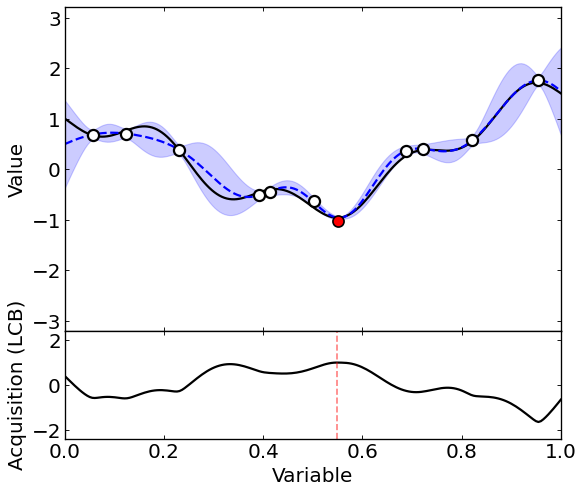

--------------------------------------------------
Optimization Finished using LCB.
Global Best Found: y = -1.019481


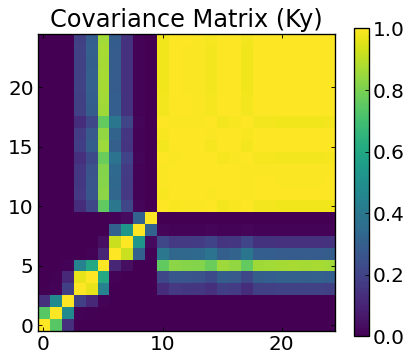

In [2]:
# -------------------- 1. Setup & Aliasing --------------------
kernel = lib_debug.rbf_kernel

# -------------------- 2. Settings --------------------
# Hyperparameters
gamma = 65.0
noise_std = 0.05
noise_var = noise_std ** 2

# Domain settings
dims = 1
lower_bounds = [0.0]
upper_bounds = [1.0]

# Optimization Loop Settings
n_init = 10
n_iter = 15
xi = 0.01

# Grid for plotting ONLY (No longer used for search loop)
X_grid = np.linspace(0, 1, 200)[:, None]

# --- Acquisition Function Selection ---
STRATEGY = "LCB"  # Options: "EI" or "LCB"

if STRATEGY == "EI":
    acq_func = lib_debug.expected_improvement
    acq_params = {'xi': 0.01}
elif STRATEGY == "LCB":
    acq_func = lib_debug.lower_confidence_bound
    acq_params = {'kappa': 2.0}
else:
    raise ValueError("Unknown strategy")

print(f"--- Strategy Selected: {STRATEGY} ---")

# -------------------- 3. Initialization --------------------
# Generate samples and observations
X_train = lib_debug.LHSsampler(dims, n_init, lower_bounds, upper_bounds)
X_train = X_train[np.argsort(X_train[:, 0])]
y_train = lib_debug.test_1D(X_train).reshape(-1, 1) + np.random.normal(0, noise_std, (len(X_train), 1))

# Keep copy for plotting
X_init_plot = X_train.copy()
y_init_plot = y_train.copy()

# -------------------- 4. Bayesian Optimization Loop --------------------
print(f"--- Starting Optimization Loop ({n_iter} iterations) ---")
print(f"{'Iter':<5} | {'Best y':<10} | {'New y':<10} | {'New x (approx)'}")
print("-" * 50)

for i in range(n_iter):
    
    # 1. Fit GP (Calculate Ky_inv)
    Ky_inv = lib_debug.fit_gp(kernel, X_train, gamma, noise_var)

    # 2. Find Next Point (Continuous Optimization instead of Grid Search)
    x_new, _ = lib_debug.optimize_acquisition(
        kernel, 
        acq_func, 
        X_train, y_train, Ky_inv, gamma, 
        lower_bounds, upper_bounds, acq_params
    )
    
    # 3. Evaluate True Function
    # x_new comes out as (dims,), need reshape for evaluation
    y_new = lib_debug.test_1D(x_new.reshape(1, -1)) + np.random.normal(0, noise_std, (1, 1))

    # 4. Update Data
    X_train = np.vstack([X_train, x_new])
    y_train = np.vstack([y_train, y_new])
    
    # Log
    current_best = np.min(y_train)
    print(f"{i+1:<5} | {current_best:.6f}   | {y_new.item():.6f}   | [{x_new[0]:.2f}]")


# -------------------- 5. Final Calculation & Visualization --------------------
# Re-fit GP with all data
Ky_inv = lib_debug.fit_gp(kernel, X_train, gamma, noise_var)

# Get predictions and acquisition values for plotting
# (Here we still use X_grid to draw the curves)
mu_list = []
sigma_list = []
acq_final_list = []

for x in X_grid:
    m, s = lib_debug.get_posterior(kernel, x, X_train, y_train, Ky_inv, gamma)
    mu_list.append(m)
    sigma_list.append(s)
    acq_final_list.append(acq_func(kernel, x, X_train, y_train, Ky_inv, gamma, **acq_params))

mu_post = np.array(mu_list)
s_post = np.array(sigma_list)
acq_final = np.array(acq_final_list)

# Identify Best Point
best_idx_final = np.argmin(y_train)
best_x = X_train[best_idx_final]
best_y = y_train[best_idx_final]

# Visualization
lib_debug.plot_gp_results(
    X_grid=X_grid,
    true_func=lib_debug.test_1D,
    X_init=X_init_plot,
    y_init=y_init_plot,
    best_x=best_x,
    best_y=best_y,
    mu=mu_post,
    sigma=s_post,
    acq_values=acq_final,
    strategy_name=STRATEGY
)

print("-" * 50)
print(f"Optimization Finished using {STRATEGY}.")
print(f"Global Best Found: y = {y_train[best_idx_final].item():.6f}")

# Final Covariance Plot
K_final = kernel(X_train, X_train, gamma)
lib_debug.plot_covariance_matrix(K_final)